## Лабораторная работа №4<br>
**Задание:** решить 2 задачи из _"Сборника задач и упражнений по теории вероятностей" Д.А. Коршунов, С.Г.Фосс_ <br> Найти приближенные решения, применяя метод монте-карло, сравнить их с правильным ответом.

### Задача 1 (2.7)
Бросаются $4$ игральные кости. Найти вероятность того, что на них выпадет по одинаковому числу очков.

In [21]:
# Импортируем библиотеки, которые понадобятся
import random
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

Решение:<br>
Бросаются $4$ независимые игральные кости, получаем $6^{4}$ равновероятных исходов. Событие, что "все выпавшие числа одинаковые", означает, что на всех выпало одинаковое число от $1$ до $6$, значит благоприятных исходов $6$. Значит: $$P = \frac{6}{6^{4}} = \frac{1}{216}$$

#### Решение с помощью метода Монте-Карло

In [8]:
# Задаем зерно датчика
random.seed(42)

# Задаем параметры эксперимента
# Число экспериментов
n_exp = 1000000

#  Обнуляем счетчик числа благоприятных событий
k_success=0

prob_tmp = []

for i in range(n_exp):
    # Подбрасываем 4 кубика в каждом испытании
    d1 = random.randint(1,6)
    d2 = random.randint(1,6)
    d3 = random.randint(1,6)
    d4 = random.randint(1,6)

    # Проверяем благоприятность исхода
    if d1 == d2 == d3 == d4:
        k_success += 1
    prob_tmp.append(k_success/(i+1))


res_mk = np.round(k_success/n_exp, 4)
res_prob = np.round(1/216, 4)

print('Вероятность, используя метод Менте-Карло равна', res_mk)
print('Вероятность, используя аналитический расчет равна 1/216 ~', res_prob)
print('Разница расчетов составляет', res_mk - res_prob)

Вероятность, используя метод Менте-Карло равна 0.0046
Вероятность, используя аналитический расчет равна 1/216 ~ 0.0046
Разница расчетов соcтавляет 0.0


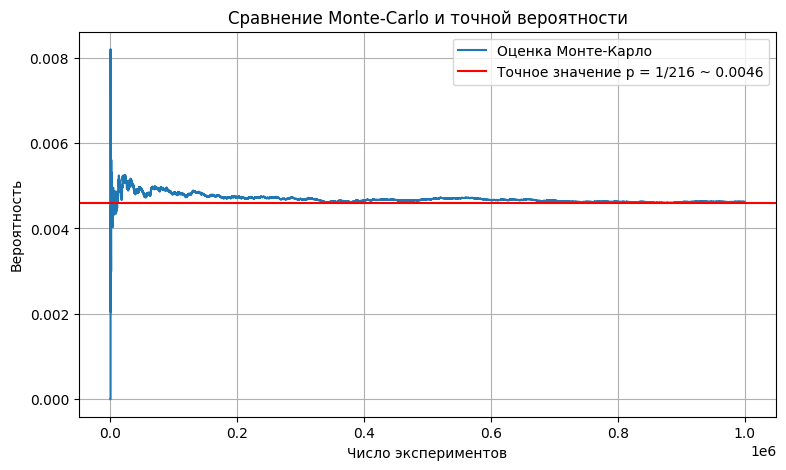

In [14]:
# Взяла большое кол-во экспериментов, построим сравнение получившихся результатов, чтобы определить значение
plt.figure(figsize=(9,5))
plt.plot(prob_tmp, label="Оценка Монте-Карло")
plt.axhline(res_prob, color = "r", label="Точное значение p = 1/216 ~ 0.0046")
plt.xlabel("Число экспериментов")
plt.ylabel("Вероятность")
plt.title("Сравнение Monte-Carlo и точной вероятности")
plt.legend()
plt.grid(True)
plt.show()

Начиная с 200 000 экспериментов разница между вероятностью по Монте-Карло и фактической становится минимальной и при более 750 000 экспериментов уже полностью совпадает.

#### Задача 2 (3.8)
Стержень длины $l$ разломан в двух наудачу выбранных точках. С какой вероятностью из полученных отрезков можно составить треугольник?

Решение: Стержень разломан в двух произвольных точках $x$ и $y$, тогда представим получившиеся отрезки $$a = x, b = y - x, c = l - y$$
Можем составить треугольник, если выполняются неравенства треугольника: $$ a+b > c, b+c > a, a+c > b$$

In [19]:
# Задаем зерно датчика
random.seed(42)

# Длина стержня
l = 1
# Число экспериментов
n_exp = 100000

#  Обнуляем счетчик числа благоприятных событий
k_success=0

prob_tmp = []

for i in range(n_exp):
    x, y = sorted((random.uniform(0,l), random.uniform(0,l)))

    a = x
    b = y - x
    c = l - y


    # Проверяем благоприятность исхода
    if a + b >c and a+c>b and b+c>a:
        k_success += 1
    prob_tmp.append(k_success/(i+1))


res_mk = np.round(k_success/n_exp, 4)
res_prob = 1/4

print('Вероятность, используя метод Менте-Карло равна', res_mk)
print('Вероятность, используя аналитический расчет равна 1/4 = ', res_prob)
print('Разница расчетов составляет', res_mk - res_prob)

Вероятность, используя метод Менте-Карло равна 0.248
Вероятность, используя аналитический расчет равна 1/4 =  0.25
Разница расчетов составляет -0.0020000000000000018


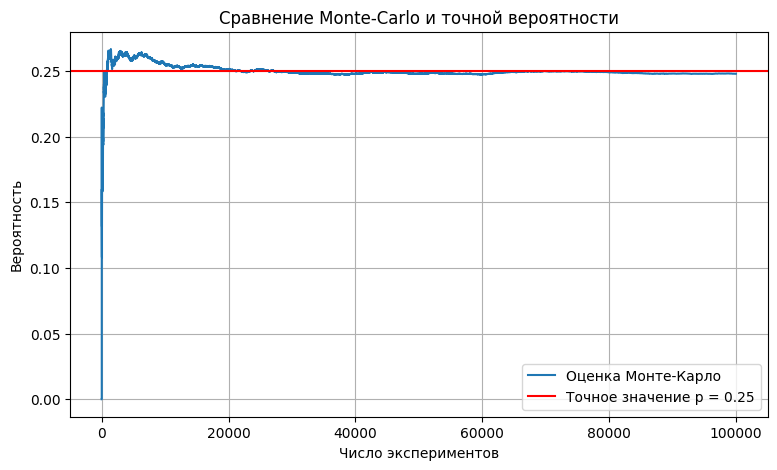

In [20]:
# Взяла большое кол-во экспериментов, построим сравнение получившихся результатов, чтобы определить значение
plt.figure(figsize=(9,5))
plt.plot(prob_tmp, label="Оценка Монте-Карло")
plt.axhline(res_prob, color = "r", label="Точное значение p = 0.25")
plt.xlabel("Число экспериментов")
plt.ylabel("Вероятность")
plt.title("Сравнение Monte-Carlo и точной вероятности")
plt.legend()
plt.grid(True)
plt.show()

Так как изначально подразумевается только один стержень, то кол-во экспериментов было выбрано меньше, как можно заметить из графика, то после 20 000 экспериментов вероятности сходятся.

Можно сделать вывод, что метод Монте-Карло эффективен для решения задач и при большем кол-во экспериментов, ближе находится к действительной вероятности. Кол-во экспериментов для каждого случая будет разным, но заметно, что, чем меньше изначальных попыток по задаче, тем меньше их нужно, например, в задаче 1 одновременно бросали 4 кубика и при 750 000 экспериментов, значения совпадали. В задаче 2 только один стержень и уже при 20 тысячах была достигнута точность.